In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
path = "/home/shahid/Desktop/new datasets/heart disease/heart_disease_ai/data/raw/heart_disease_cleveland.csv"
df = pd.read_csv(path)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


# 1. Correlation Heatmap

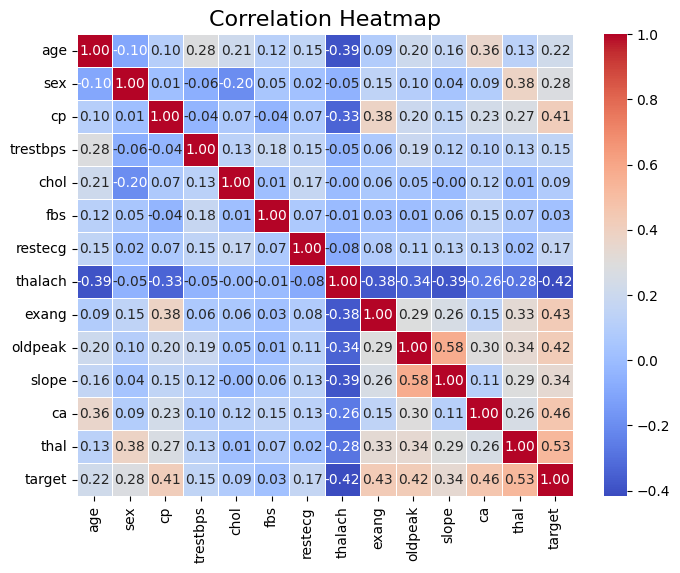

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

#  2. Target-wise Analysis
### 🔹 Boxplots (Feature vs Target)

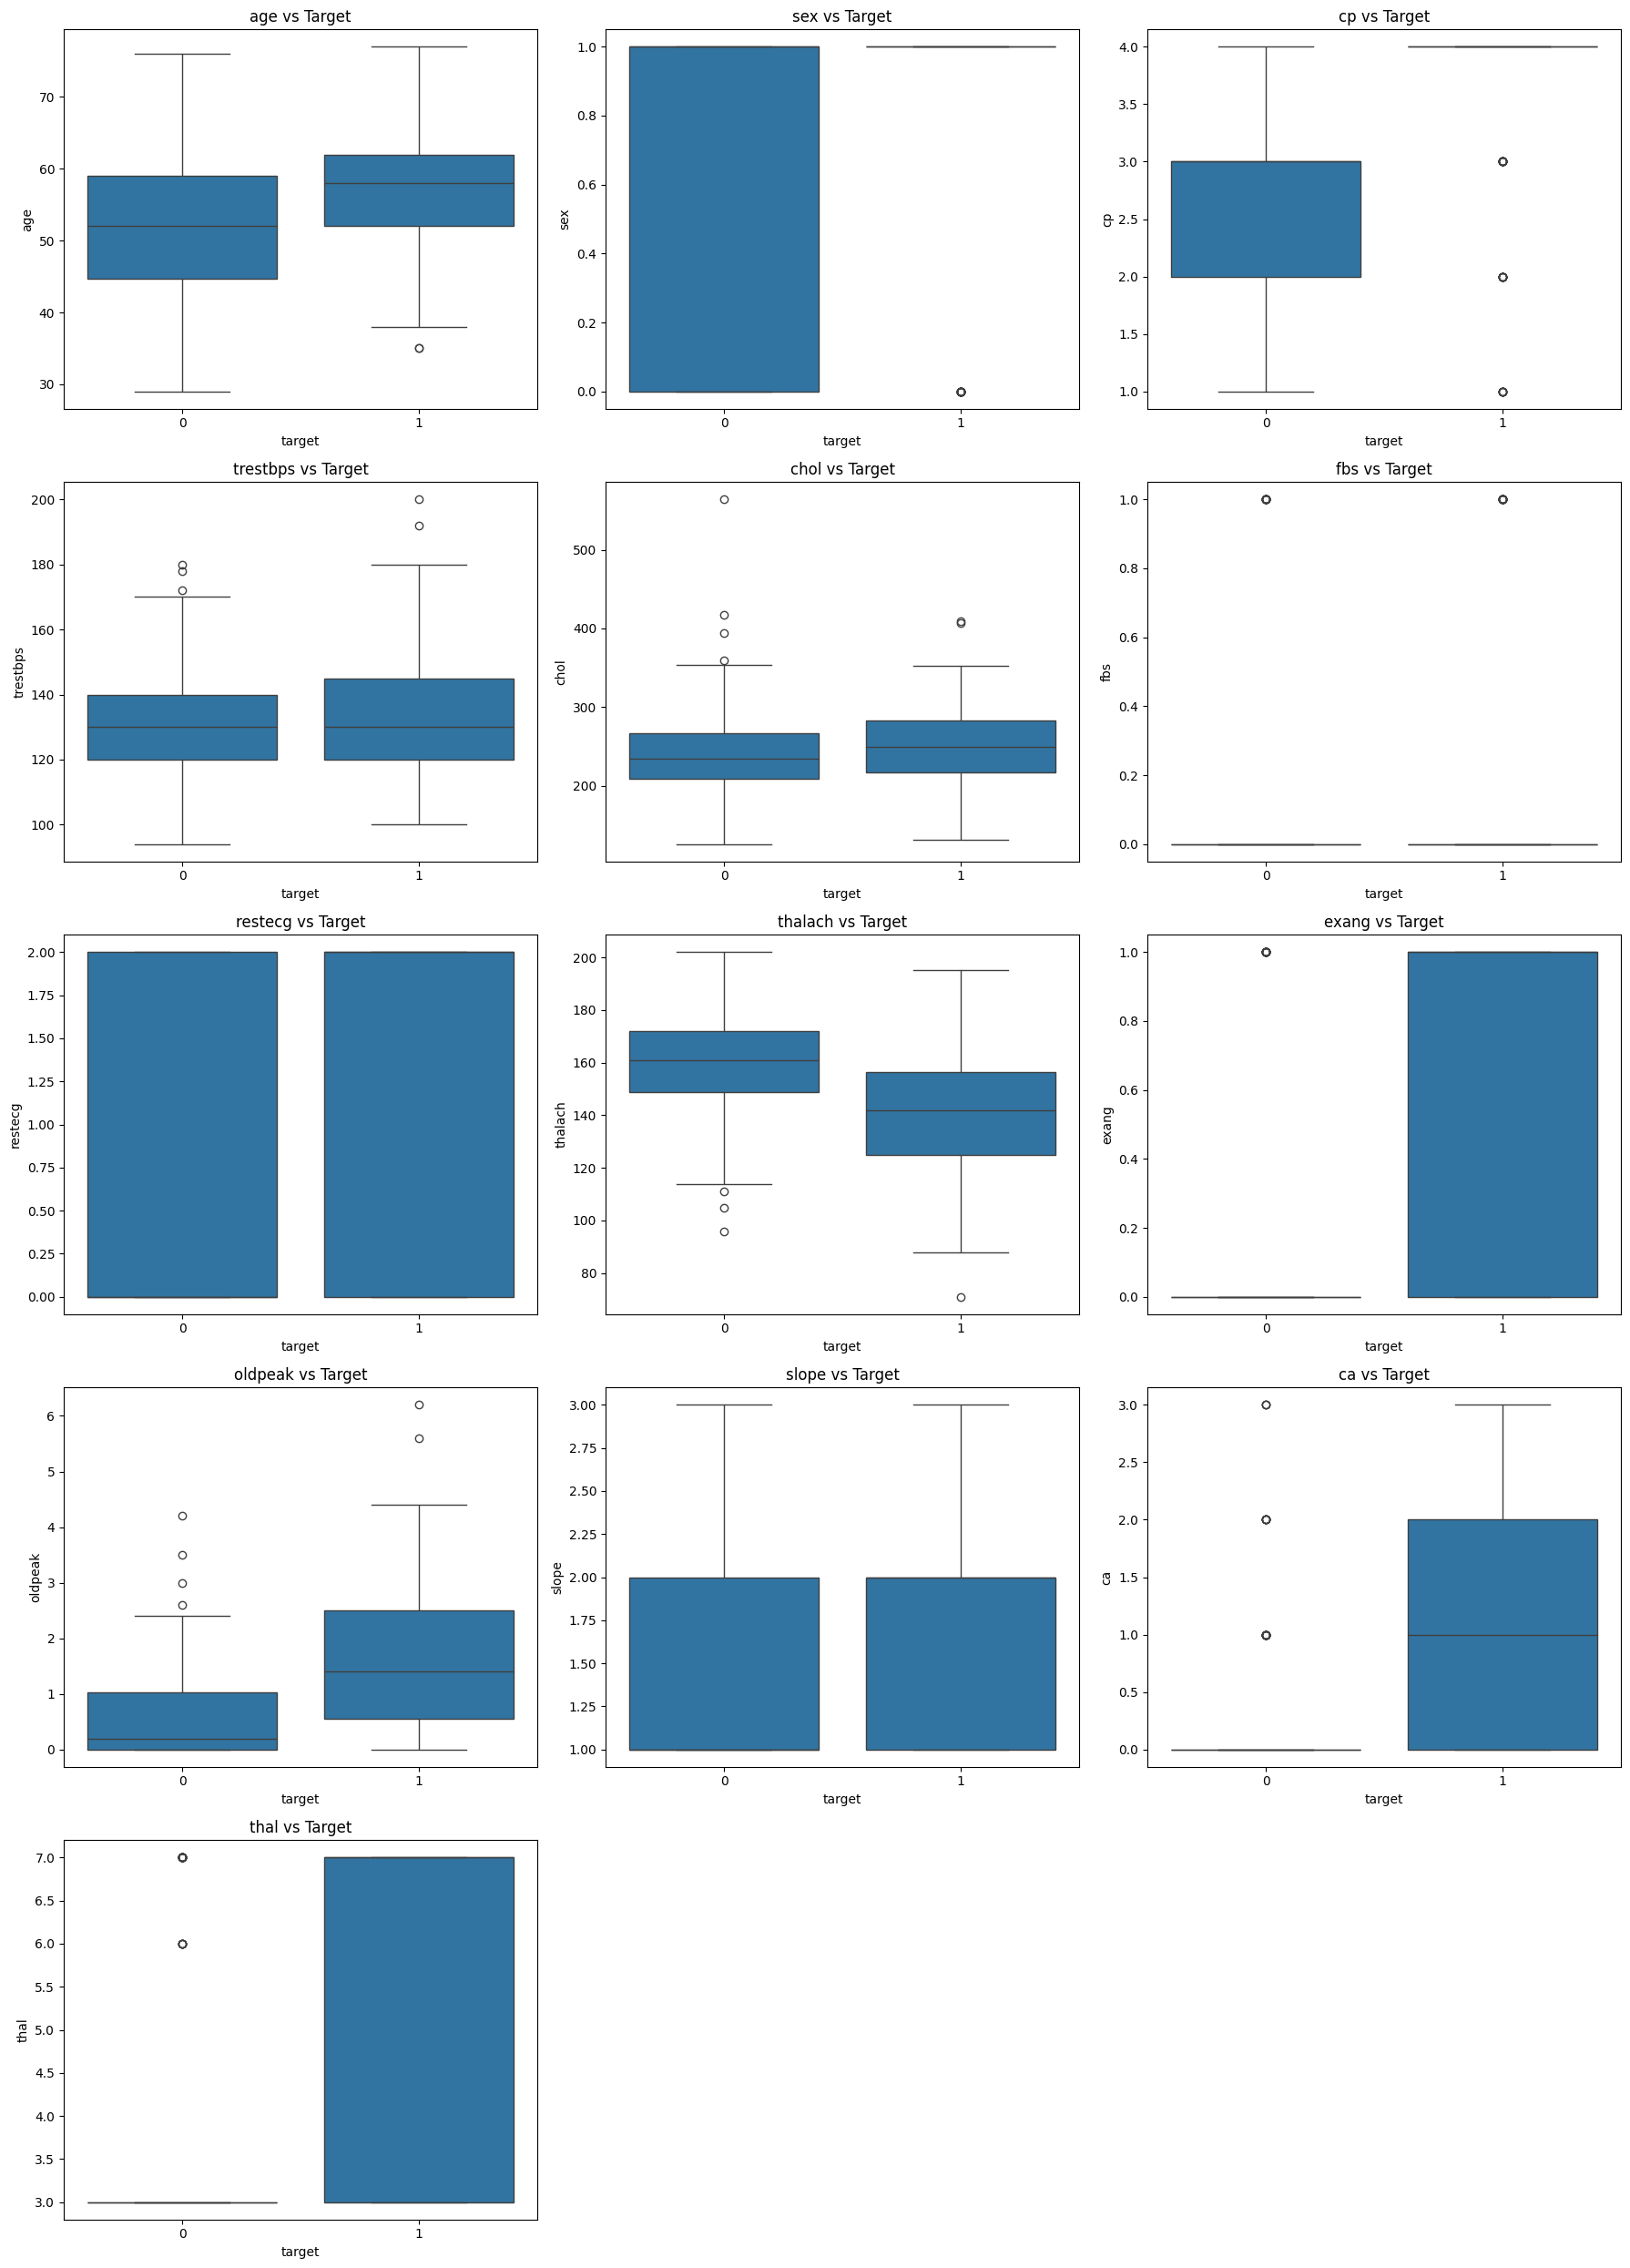

In [29]:
features = df.columns.drop("target")
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x="target", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 3. Grouped Mean

In [14]:
grouped_means = df.groupby("target").mean()

print(grouped_means)

              age       sex        cp    trestbps        chol       fbs  \
target                                                                    
0       52.585366  0.560976  2.792683  129.250000  242.640244  0.140244   
1       56.625899  0.820144  3.589928  134.568345  251.474820  0.158273   

         restecg     thalach     exang   oldpeak     slope        ca      thal  
target                                                                          
0       0.835366  158.378049  0.140244  0.586585  1.408537  0.273292  3.797546  
1       1.172662  139.258993  0.546763  1.574101  1.827338  1.137681  5.840580  


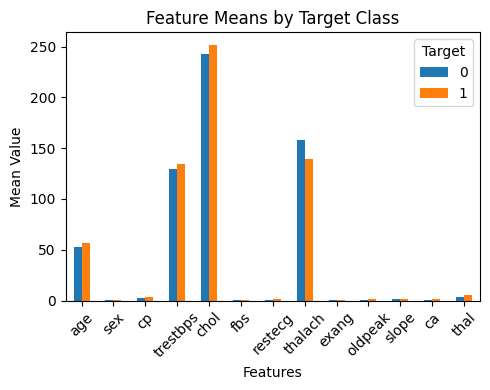

In [27]:
grouped_means.T.plot(kind="bar", figsize=(5, 4))
plt.title("Feature Means by Target Class")
plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.legend(title="Target")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Distribution Plots (Histograms + KDE)

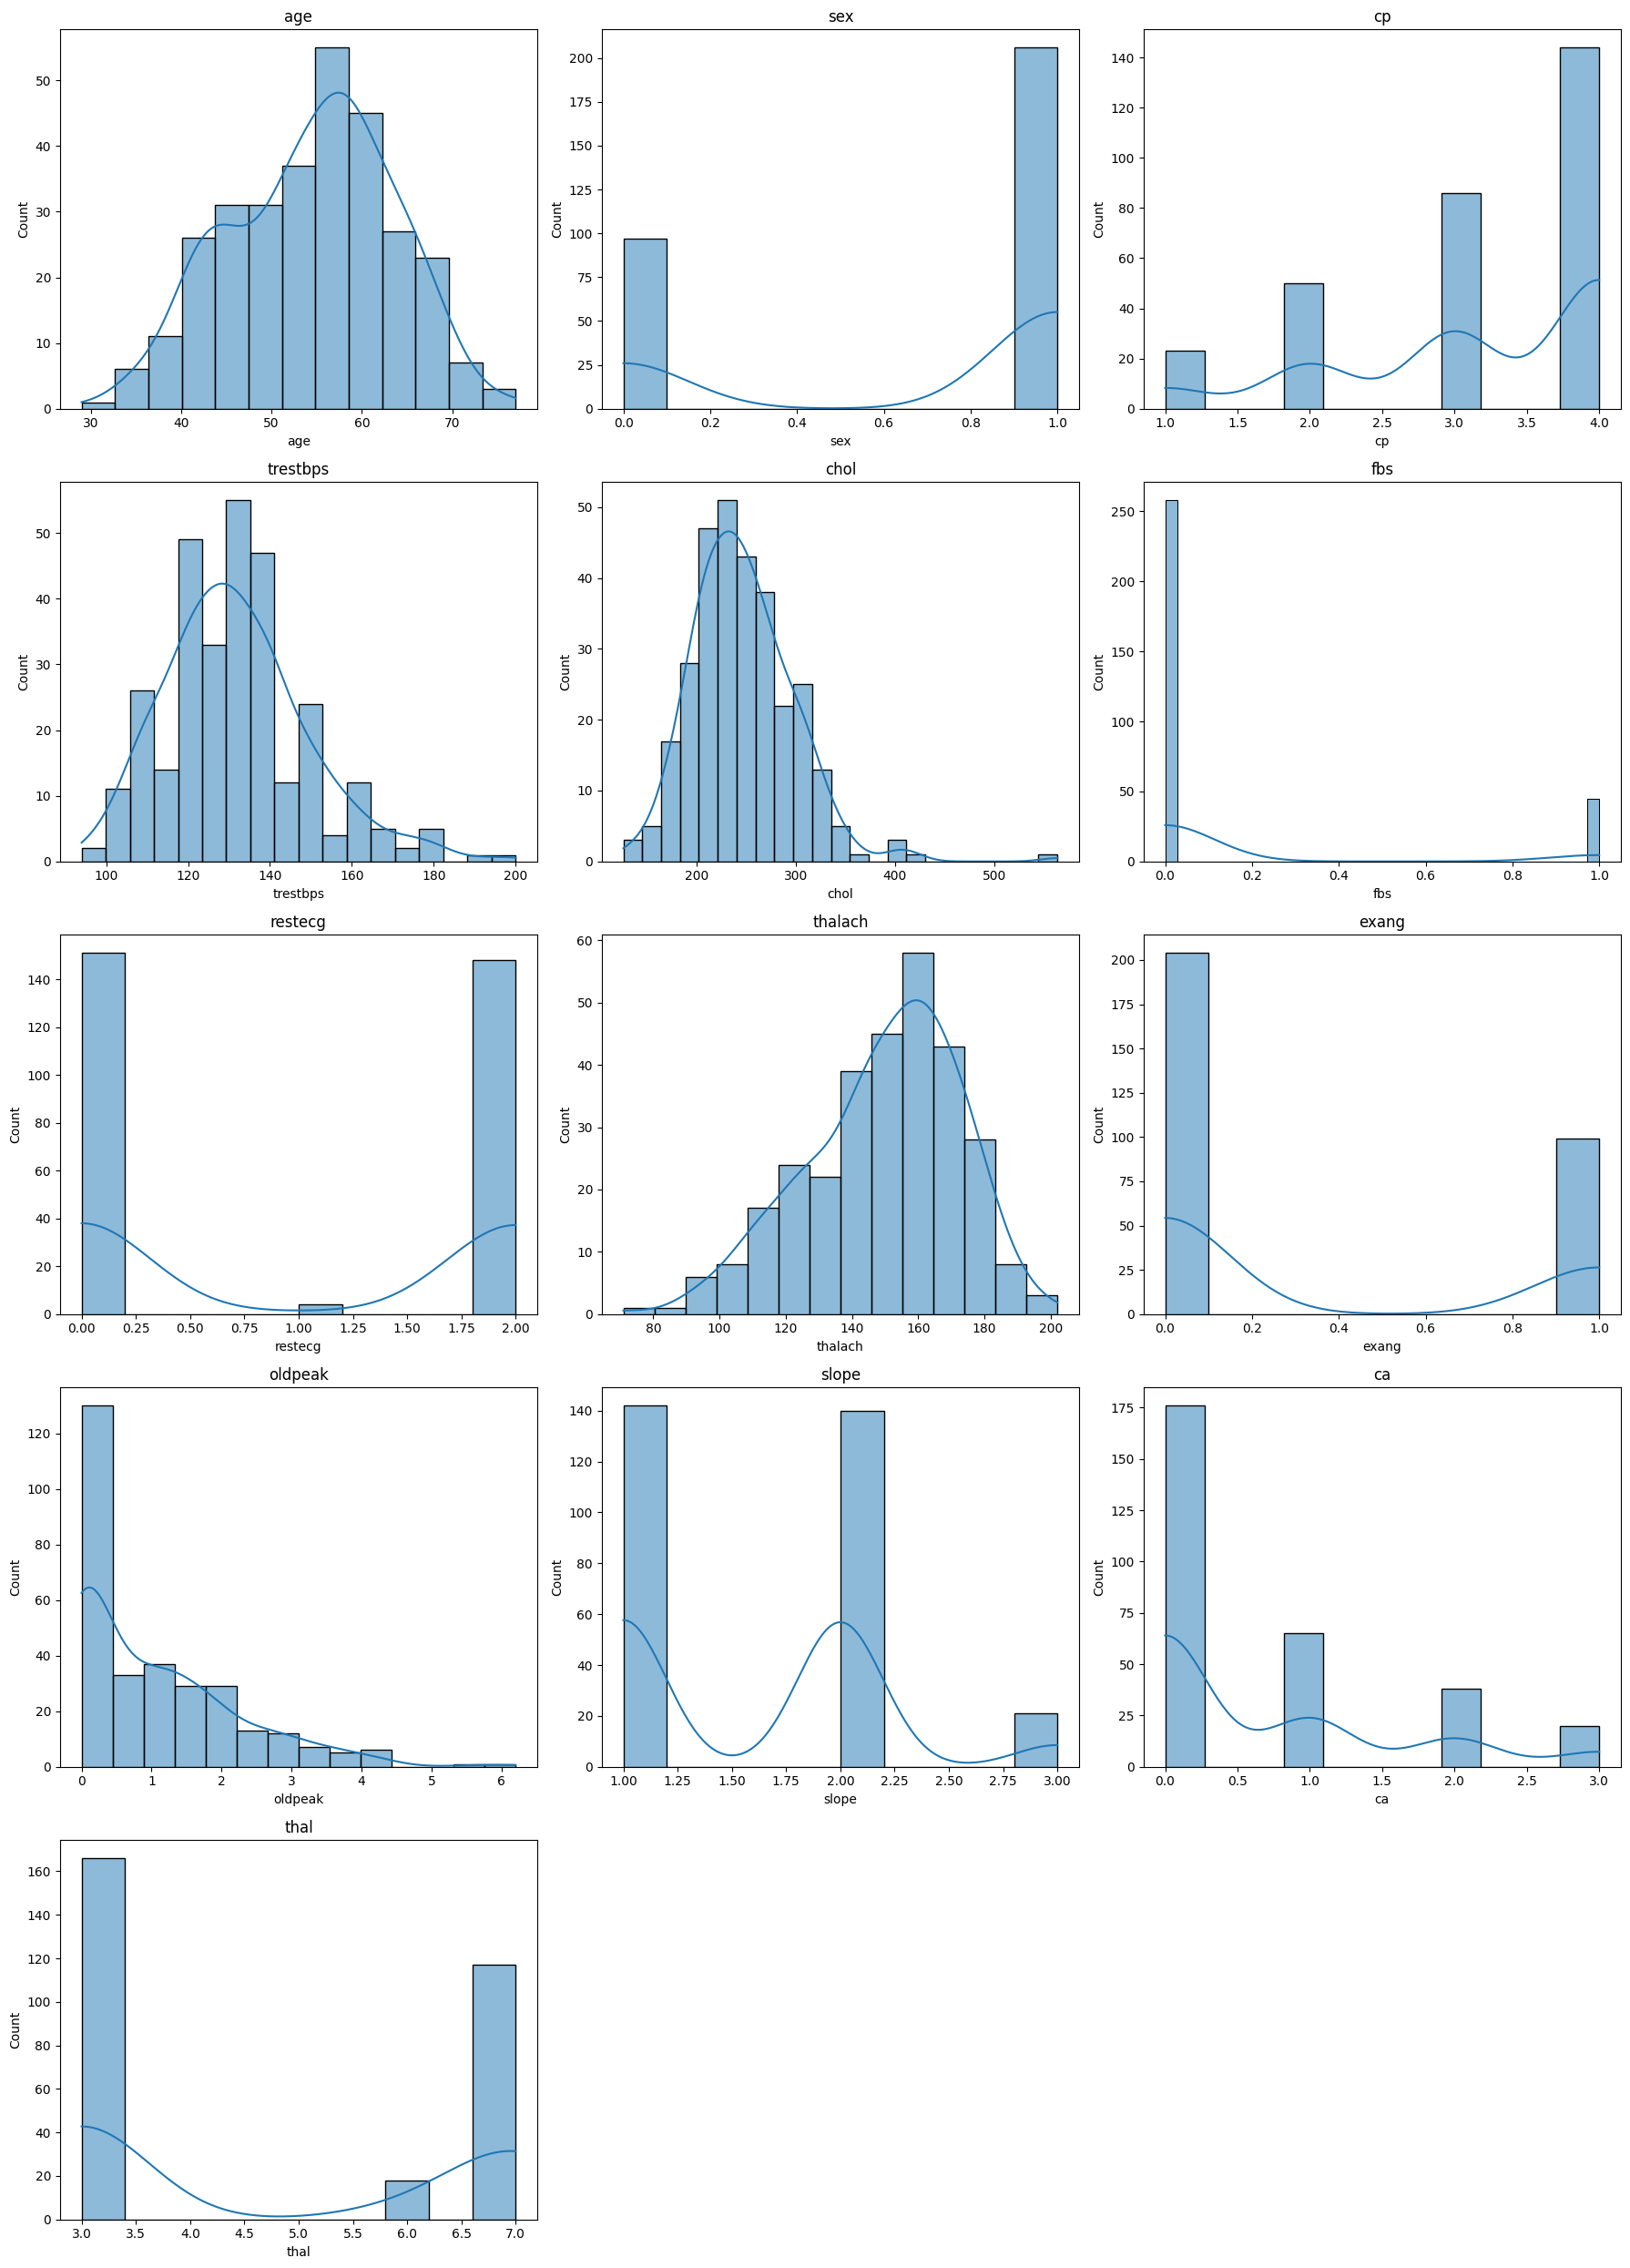

In [25]:
import math

features = df.columns.drop("target")
n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 5. Outlier Detection (Important Features)
### 🔹 Boxplots for Key Features

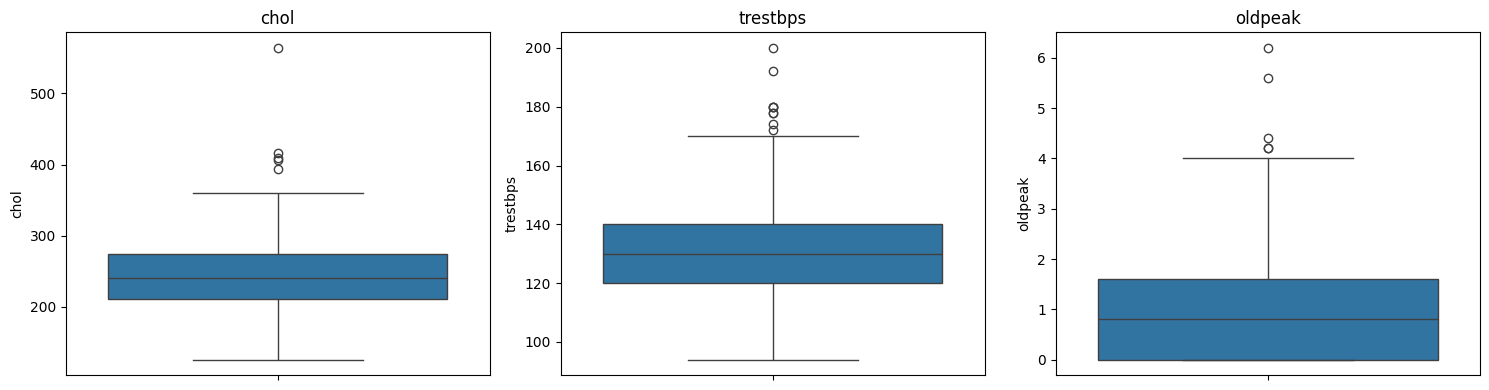

In [30]:
outlier_features = ["chol", "trestbps", "oldpeak"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(outlier_features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Target-wise Outliers (more insightful)

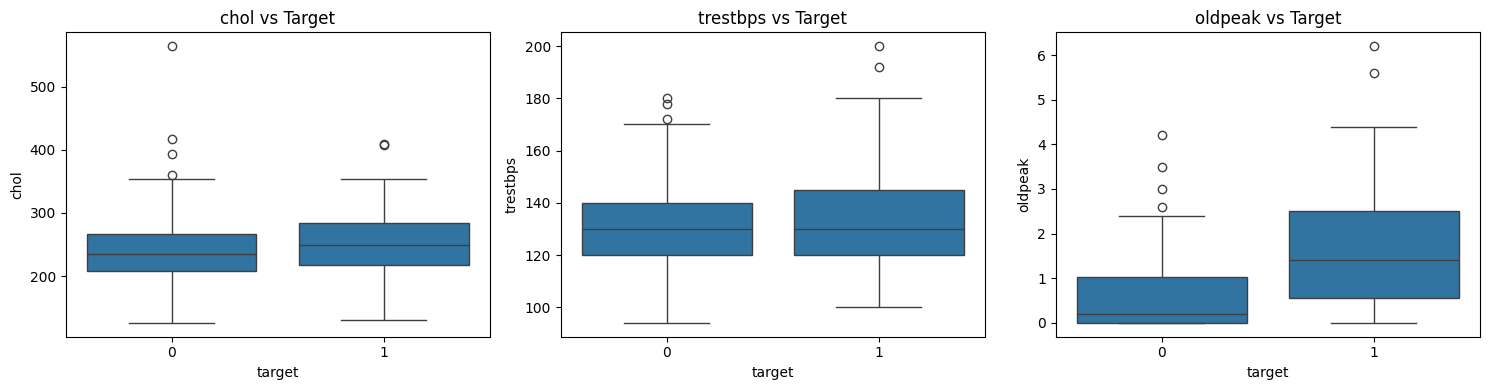

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(outlier_features):
    sns.boxplot(x="target", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")

plt.tight_layout()
plt.show()

# 6. Target Distribution Visualization

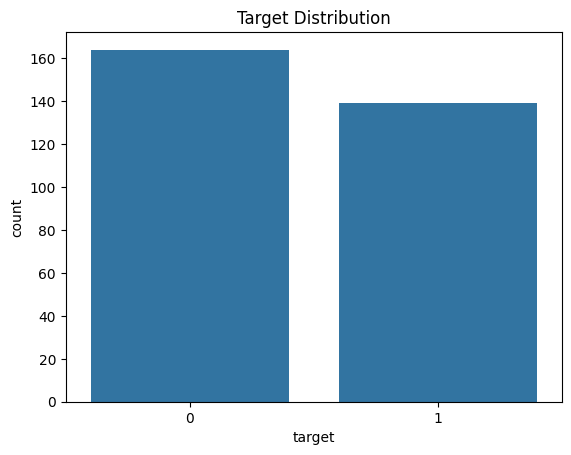

In [32]:
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()

# 7. Feature Importance (Quick Pre-Model Insight)

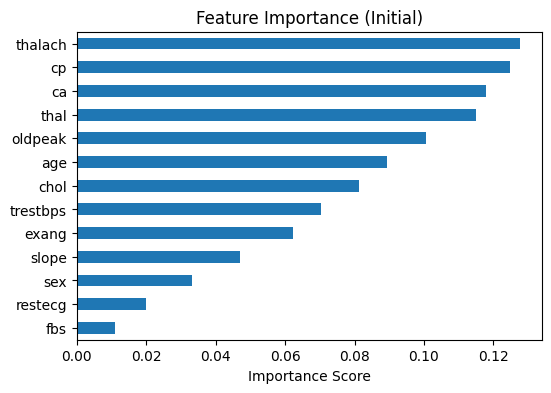

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Fill missing values first
df_filled = df.fillna(df.median())
# Define features and target
X = df_filled.drop("target", axis=1)
y = df_filled["target"]

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)

# Plot
importances.sort_values().plot(kind="barh", figsize=(6,4))
plt.title("Feature Importance (Initial)")
plt.xlabel("Importance Score")
plt.show()

# 8. Multicollinearity Check

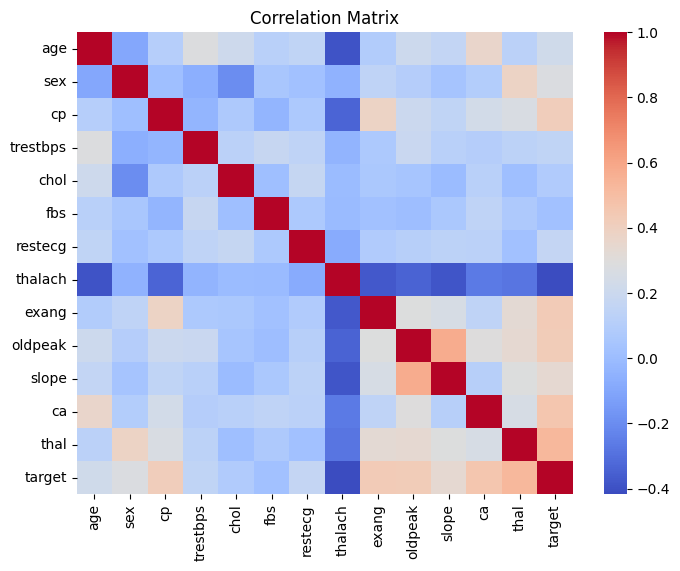

In [39]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 9. PairPlot
- Feature interaction patterns

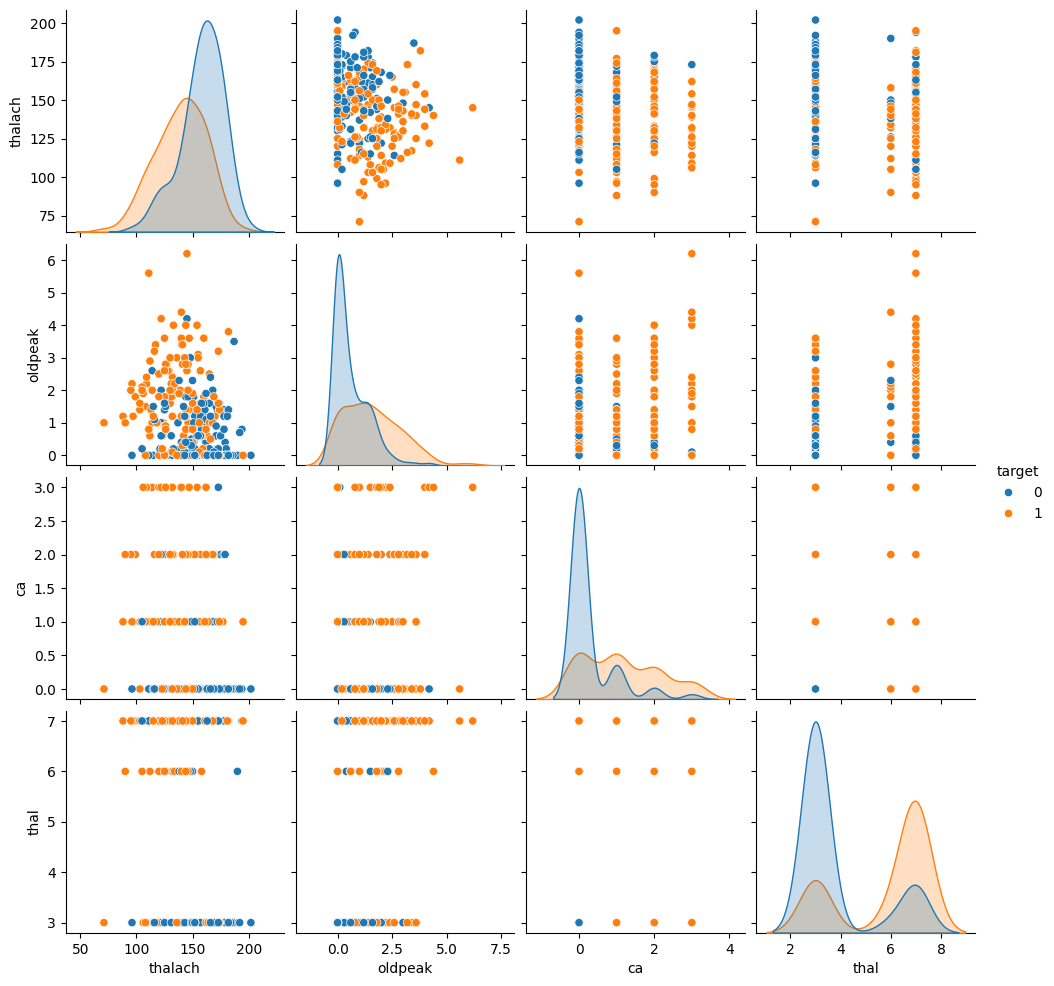

In [35]:
sns.pairplot(df[["thalach", "oldpeak", "ca", "thal", "target"]], hue="target")
plt.show()

# 10. Categorical Feature Analysis

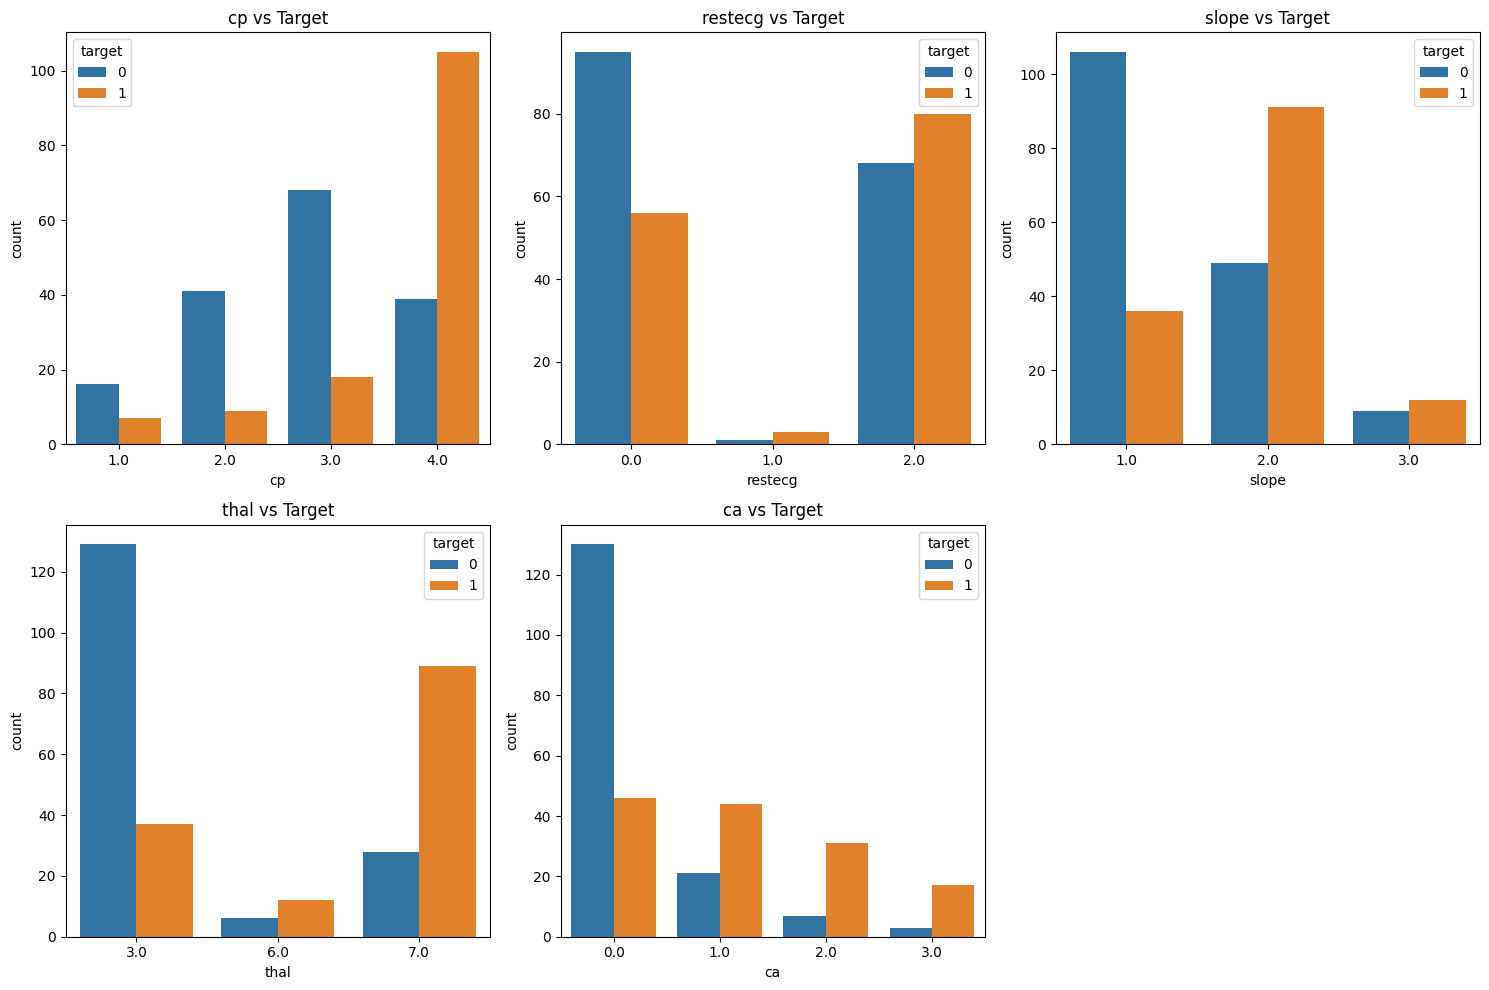

In [43]:
import math
cat_features = ["cp", "restecg", "slope", "thal", "ca"]

n_cols = 3
n_rows = math.ceil(len(cat_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue="target", data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 11. Skewness Check

In [37]:
skewness = df.skew()
print(skewness.sort_values(ascending=False))

fbs         1.986652
oldpeak     1.269720
ca          1.189352
chol        1.135503
exang       0.742532
trestbps    0.706035
slope       0.508316
thal        0.244447
target      0.166406
restecg     0.019900
age        -0.209060
thalach    -0.537449
sex        -0.774935
cp         -0.841754
dtype: float64


# 12. Missing Value Strategy Justification

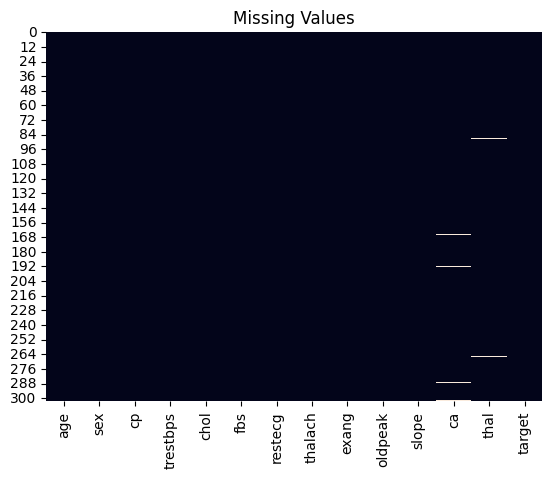

In [38]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()